In [1]:
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import pandas as pd

from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [3]:
transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

dataset = ImageFolder(

    "../dataset/UCMerced",

    transform=transform

)

loader = DataLoader(

    dataset,

    batch_size=1,

    shuffle=False

)

In [4]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(

    model.fc.in_features,

    21

)

model.load_state_dict(

    torch.load(

        "../models/resnet18_ucmerced_final.pth",

        map_location=device

    )

)

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [5]:
misclassified = []

with torch.no_grad():

    for image,label in loader:

        image=image.to(device)

        output=model(image)

        _,pred=torch.max(output,1)

        if pred.item()!=label.item():

            misclassified.append(

                (

                    image.cpu(),

                    label.item(),

                    pred.item()

                )

            )

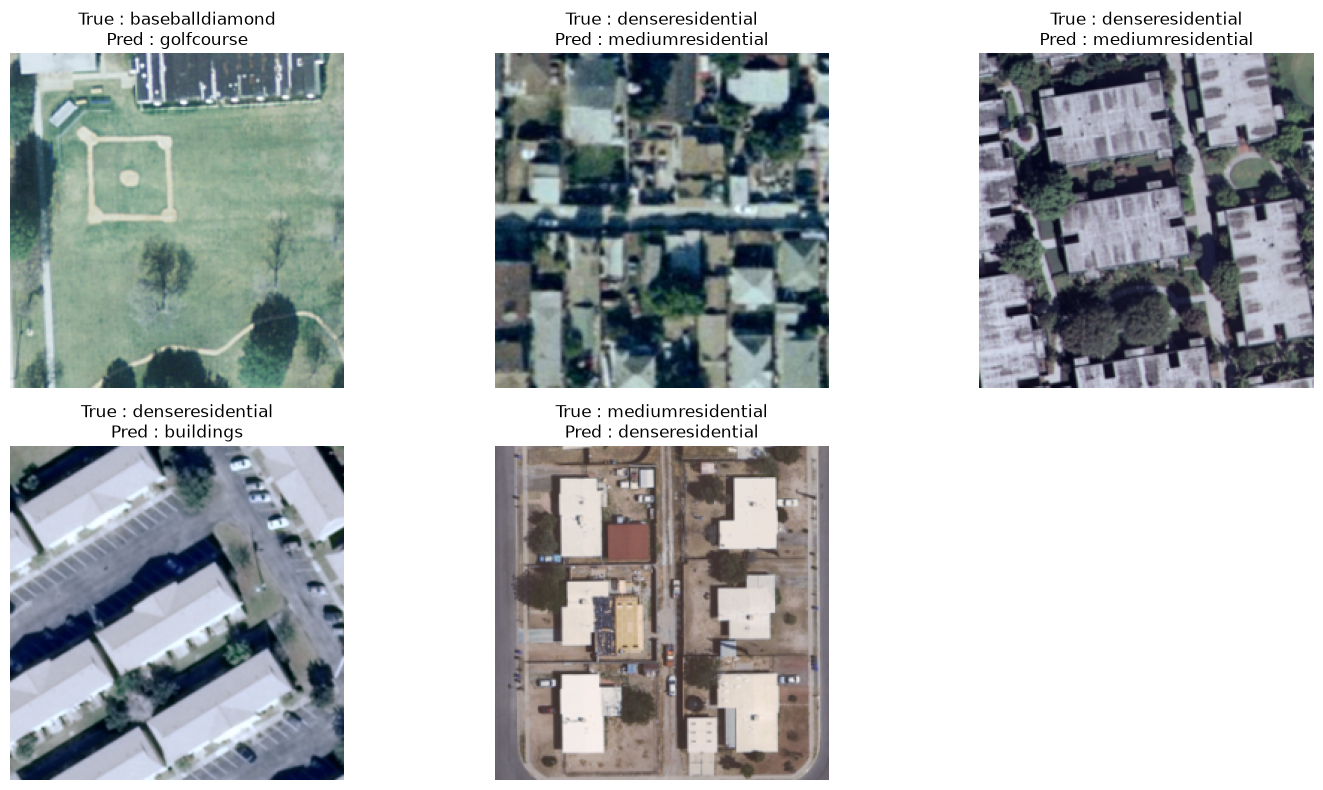

In [6]:
classes = dataset.classes

plt.figure(figsize=(15,8))

for i in range(min(5,len(misclassified))):

    image,true_label,pred_label = misclassified[i]

    img=image.squeeze().permute(1,2,0)

    img=img.numpy()

    img=img*0.229+0.485

    img=img.clip(0,1)

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(

        f"True : {classes[true_label]}\n"

        f"Pred : {classes[pred_label]}"

    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [7]:
rows=[]

for i in range(min(5,len(misclassified))):

    _,true_label,pred_label=misclassified[i]

    rows.append({

        "Actual":

        classes[true_label],

        "Predicted":

        classes[pred_label],

        "Possible Reason":

        ""

    })

df=pd.DataFrame(rows)

df

,Actual,Predicted,Possible Reason
0,baseballdiamond,golfcourse,
1,denseresidential,mediumresidential,
2,denseresidential,mediumresidential,
3,denseresidential,buildings,
4,mediumresidential,denseresidential,
